# Dataset folder structure
```
data/
│
├── images/                              # PNG files
│   ├── 0.png                           
│   │   .
│   │   .
│   │   .
│   └── 1.png                          
│
└── labels.json                                # json dict of files


In [1]:
from pathlib import Path

MODEL='Version4.1'

EPOCHS=1

LR=1e-4

DATASET_PATH = Path('preprocessed_data/text_renderer')

DATASET_PATH.mkdir(parents=True, exist_ok=True)

AUGMENT_DATA = False


In [ ]:
import json
from pathlib import Path

if AUGMENT_DATA:
    with open(str(DATASET_PATH / 'labels.json'), 'r') as fp:
        data_dict = json.load(fp)

    print(f"{len(data_dict.items())} dict elements")

In [3]:
from util.augmentation import augment_dataset
from util.data_processing import save_labels

if AUGMENT_DATA:
    augment_dataset(data_dict, 3, 3, 3, 'preprocessed_data/text_renderer/images/')
    save_labels(data_dict, DATASET_PATH / 'augmented_labels.json')

In [4]:
import json
from pathlib import Path

with open(str(DATASET_PATH / 'augmented_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

tr_dict = dict()

for items in data_dict.items():
    tr_dict[str(DATASET_PATH / 'images' / items[0]) + '.jpg'] = items[1]


with open(str(Path('preprocessed_data/text_renderer_vertical') / 'augmented_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

vertical_dict = dict()

for items in data_dict.items():
    vertical_dict[str(Path('preprocessed_data/text_renderer_vertical') / 'images' / items[0]) + '.jpg'] = items[1]


# with open(str(Path('preprocessed_data/text_renderer_print') / 'augmented_labels.json'), 'r') as fp:
#     data_dict = json.load(fp)

# print_dict = dict()

# for items in data_dict.items():
#     print_dict[str(Path('preprocessed_data/text_renderer_vertical') / 'images' / items[0]) + '.jpg'] = items[1]

print(f"{len(tr_dict.items())} dict elements")

words_files = list(tr_dict.items()) + list(vertical_dict.items())
print(words_files[0])

8000000 dict elements
('preprocessed_data/text_renderer/images/000000000.jpg', 'んですね僕')


In [ ]:
from util.data_processing import get_words_list

words = get_words_list(words_files)

Building dataset: 100%|██████████| 16000000/16000000 [33:10<00:00, 8036.38it/s]  


Word(file_path='preprocessed_data/text_renderer/images/000000000.jpg', transcription='んですね僕')


# Train test split

In [6]:
from random import shuffle
import numpy as np

shuffle(words)

train_word_records, test_word_records = np.split(words, [int(len(words)*0.9)])
print(f'Train size: {len(train_word_records)}; Test size: {len(test_word_records)}')

Train size: 14400000; Test size: 1600000


# Build dataset and dataloader

In [ ]:
from util.data_processing import WORDSDataset
from dtrocr.config import DTrOCRConfig

config = DTrOCRConfig(
    # attn_implementation='flash_attention_2'
)
train_data = WORDSDataset(words=train_word_records, config=config)
test_data = WORDSDataset(words=test_word_records, config=config)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [8]:
from torch.utils.data import DataLoader
import multiprocessing as mp

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=mp.cpu_count())
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=mp.cpu_count())

# Model

In [ ]:
from util.model import get_model

model = get_model(config, MODEL)

OptimizedModule(
  (_orig_mod): DTrOCRLMHeadModel(
    (transformer): DTrOCRModel(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(4, 8), stride=(4, 8))
      )
      (token_embedding): Embedding(32000, 768)
      (positional_embedding): Embedding(256, 768)
      (hidden_layers): ModuleList(
        (0-11): 12 x GPT2Block(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): GPT2SdpaAttention(
            (c_attn): Conv1D()
            (c_proj): Conv1D()
            (attn_dropout): Dropout(p=0.1, inplace=False)
            (resid_dropout): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D()
            (c_proj): Conv1D()
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)


# Training

In [ ]:
from util.model import train

train(model, train_dataloader, test_dataloader, EPOCHS, MODEL, LR, 'Text Renderer')

Evaluating test set: 100%|██████████| 50000/50000 [1:15:14<00:00, 11.08it/s]


Epoch: 1 - Train loss: 1.1788372032402126, Train accuracy: 0.7640664814287424, Test loss: 0.4852868702119589, Test accuracy: 0.888998234937191


# Test

In [ ]:
from dtrocr.model import DTrOCRLMHeadModel
from dtrocr.config import DTrOCRConfig
from dtrocr.processor import DTrOCRProcessor
import torch
torch.save(model.state_dict(), f'../models/{MODEL}.pt')
# model = DTrOCRLMHeadModel(DTrOCRConfig())
model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/dtrocr-0.3.0-py3.12.egg/dtrocr/model.py:295: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  next_tokens = torch.argmax(torch.nn.functional.softmax(next_token_scores), dim=-1)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12455 (\N{KATAKANA LETTER SMALL E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}

フェル塔、モン   フェル塔、モン


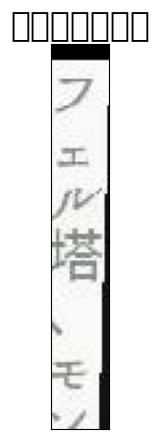

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12363 (\N{HIRAGANA LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3

ないか、と思い   ないか、と思い


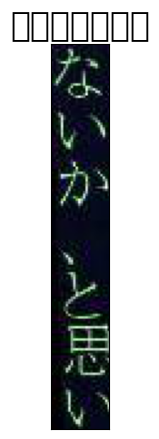

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


が   が


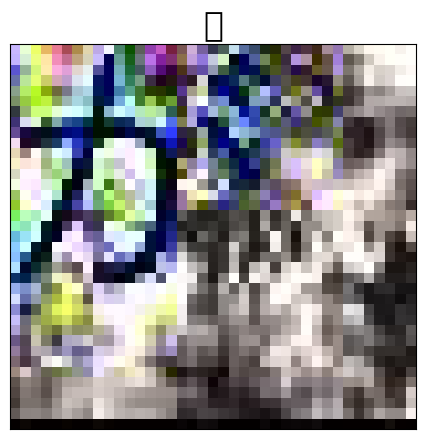

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


安   安


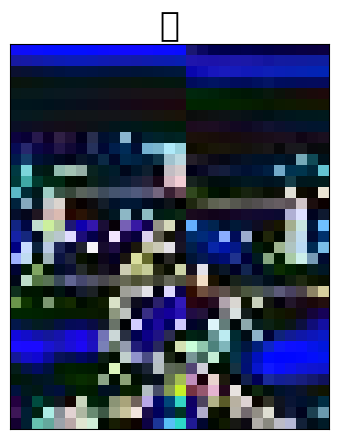

「あら見   あら見


findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12425 (\N{HIRAGANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35211 (\N{CJK UNIFIED IDEOGRAPH-898B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


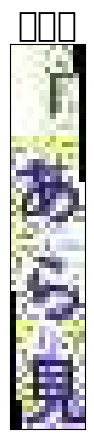

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


ノンフ   ノンフ


/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12494 (\N{KATAKANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


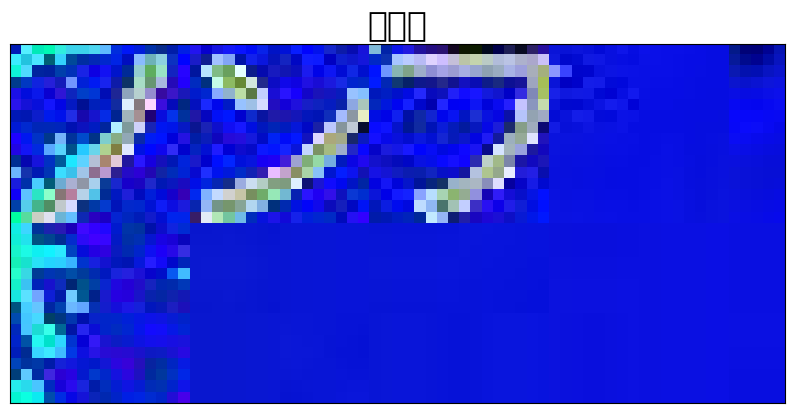

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12369 (\N{HIRAGANA LETTER KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12301 (\N{RIGHT CORNER BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35441 (\N{CJK UNIFIED IDEOGRAPH-8A71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


けない」と話   けない」と話


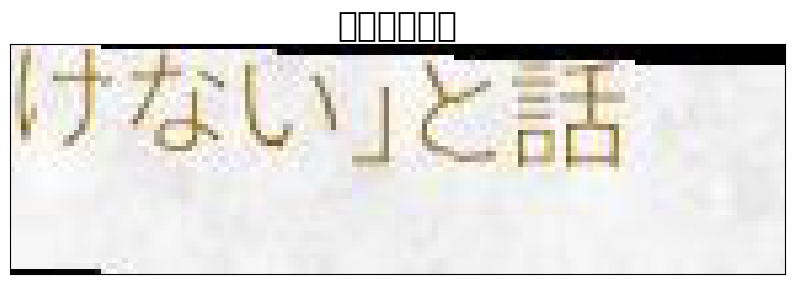

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


の   の


/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


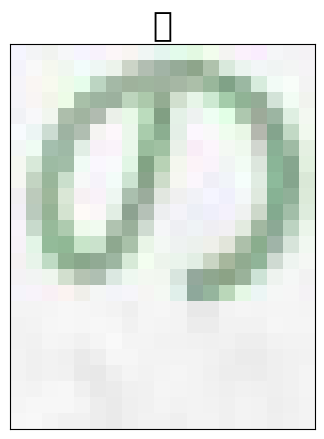

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12420 (\N{HIRAGANA LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


は、や   は、や


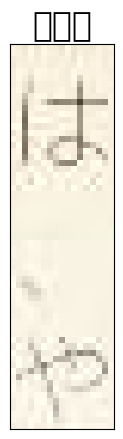

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


ー   ー


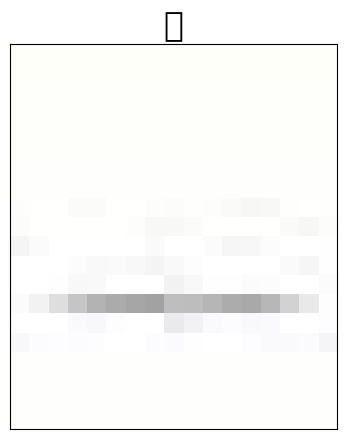

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12390 (\N{HIRAGANA LETTER TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


てい   てい


findfont: Font family 'TakaoPGothic' not found.


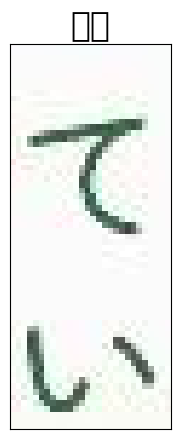

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12451 (\N{KATAKANA LETTER SMALL I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12468 (\N{KATAKANA LETTER GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33322 (\N{CJK UNIFIED IDEOGRAPH-822A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/k

ンディゴ航空は   ンディゴ航空は


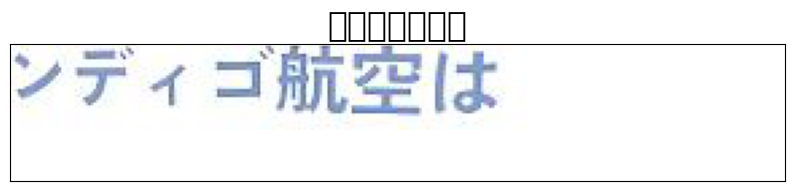

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12427 (\N{HIRAGANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/hom

号に係る部   号に係る部


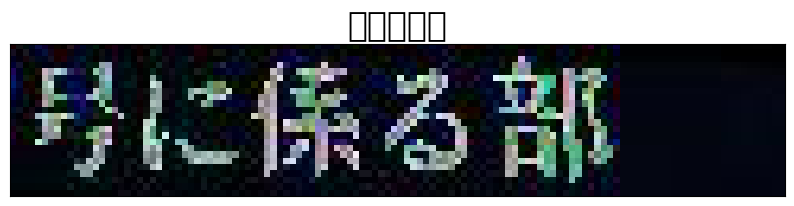

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


配達員   配


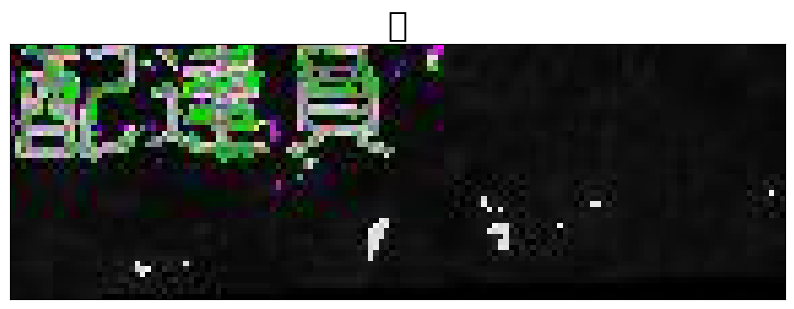

ダンスを   ダンスを


findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12480 (\N{KATAKANA LETTER DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


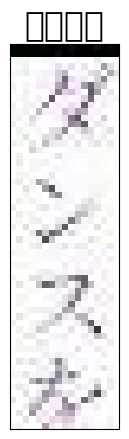

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12457 (\N{KATAKANA LETTER SMALL O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12418 (\N{HIRAGANA LETTER MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


ォークも   ォークも


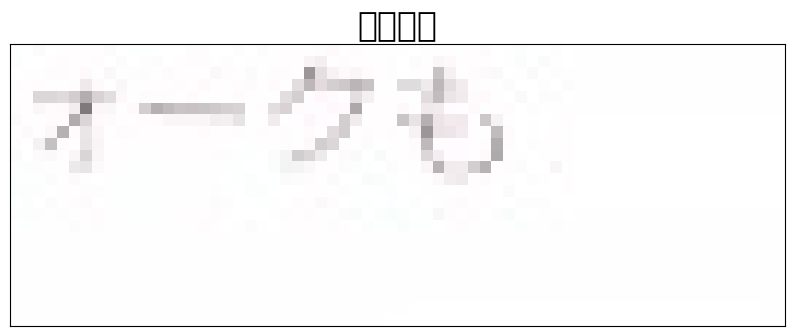

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12375 (\N{HIRAGANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12383 (\N{HIRAGANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/m

表しました。※   表しました。※


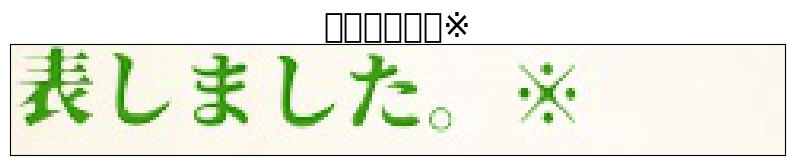

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12461 (\N{KATAKANA LETTER KI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font famil

でパンケーキを   でパンケーキを


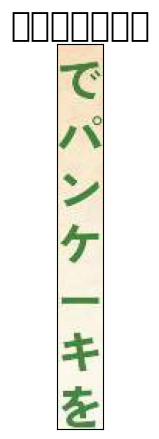

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


ると   ると


findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


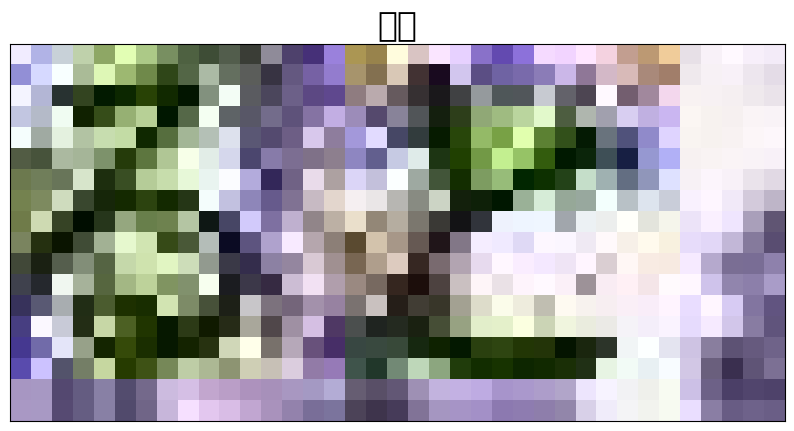

しか分   しか分


findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


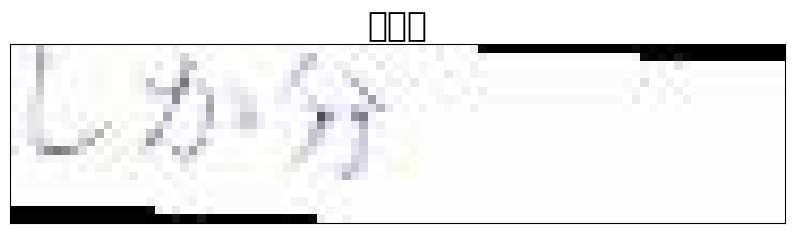

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


。   。


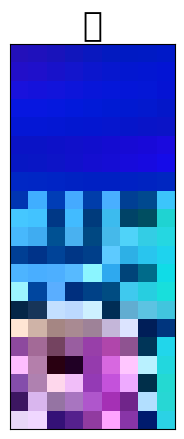

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


ますが、   ますが、


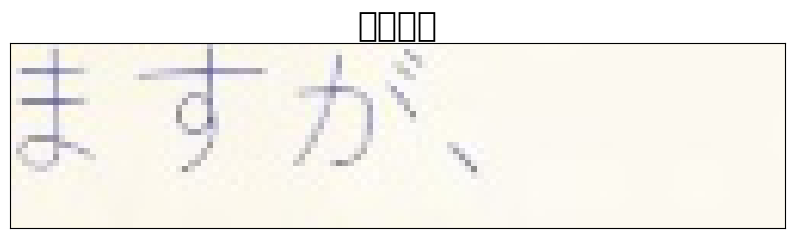

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12371 (\N{HIRAGANA LETTER KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12429 (\N{HIRAGANA LETTER RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12300 (\N{LEFT CORNER BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/

ころ「日本   ころ「日本


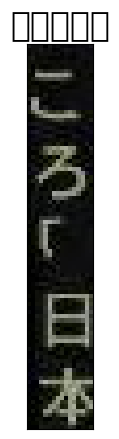

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21463 (\N{CJK UNIFIED IDEOGRAPH-53D7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21462 (\N{CJK UNIFIED IDEOGRAPH-53D6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


た」と受け取   た」と受け取


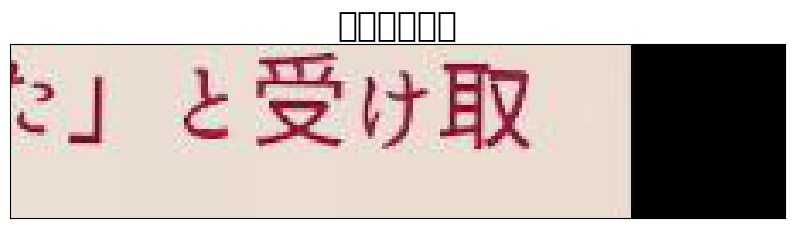

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35443 (\N{CJK UNIFIED IDEOGRAPH-8A73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12367 (\N{HIRAGANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


詳しく   詳しく


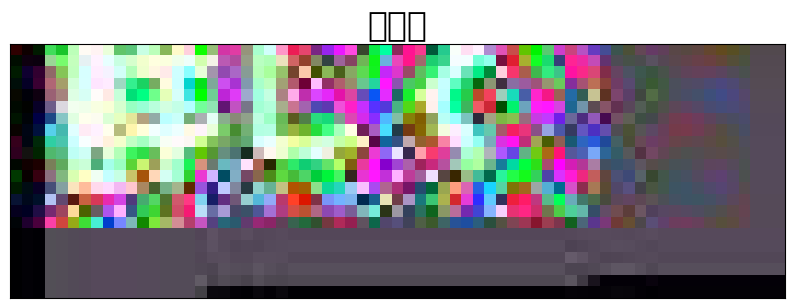

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36865 (\N{CJK UNIFIED IDEOGRAPH-9001}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


らお送   らお送


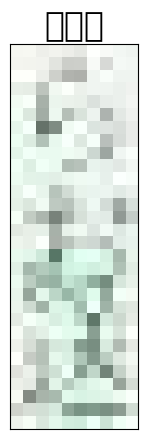

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


てとて   てとて


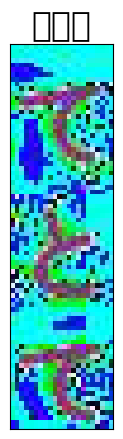

いところ   いところ


findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


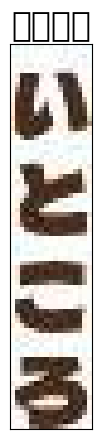

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12384 (\N{HIRAGANA LETTER DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


ます。ただ   ます。ただた


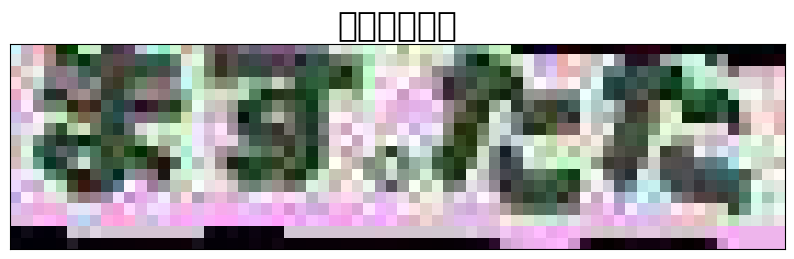

findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12435 (\N{HIRAGANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.
findfont: Font family 'TakaoPGothic' not found.


ん   ん


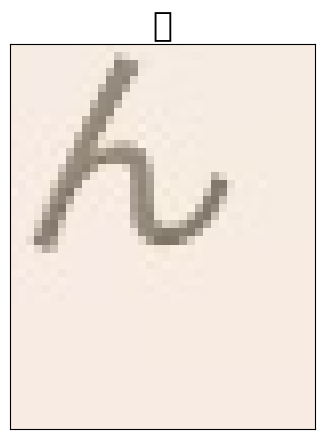

In [ ]:
from util.model import test

test(model, train_word_records, 10)

In [14]:
print(test_processor.tokeniser.decode(163).encode())

b'14'
